# Coulomb stress changes

This notebook shows an example to calculate Coulomb stress changes in a receiver fault geometry

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from vmod.data import Gnss
from vmod.source import Mogi

## Data points

In [2]:
xs=np.linspace(-5e3,5e3,100)
ys=np.linspace(-5e3,5e3,100)

XXS,YYS=np.meshgrid(xs,ys)

xs=XXS.ravel()
ys=YYS.ravel()

obs=Gnss()

obs.add_xs(xs)
obs.add_ys(ys)

## Model object

Define the model object and the parameters for the source

In [3]:
#Mogi model object
mog=Mogi(obs)

#Mogi source parameters
xcen,ycen=0,0 #Horizontal location in meters
d=3e3 #Source depth
dV=1e6 #Volume change in cubic meters
nu=0.25 #Poisson ratio
mu=32e9 #Shear modulus in Pa

## Coulomb stress changes calculation

Define the receiver fault geometry and call the function `coulomb_change`

In [4]:
#Receiver fault geometry
strike=145 #Strike in degrees
dip=90 #Dip in degrees
rake=0 #Rake in degrees
fric=0.4 #Friction coefficient

s_depth=2e3 #Slice depth in meters

shear_mog,normal_mog,coulomb_s1=mog.coulomb_change(strike,dip,rake,s_depth,fric,[xcen,ycen,d,dV,nu,mu])

## Plotting results

The output for the Coulomb stress changes are Pa. For plotting we convert it to bar

(-5.0, 5.0)

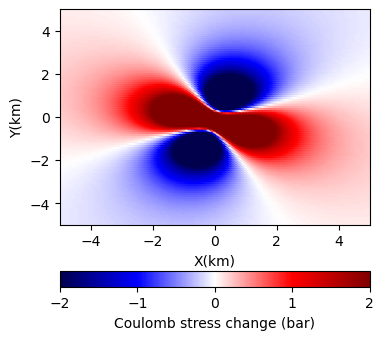

In [5]:
plt.figure(figsize=(4,4))
plt.scatter(xs/1e3,ys/1e3,c=coulomb_s1/1e5,vmin=-2,vmax=2,cmap='seismic')
plt.xlabel('X(km)')
plt.ylabel('Y(km)')
plt.colorbar(label='Coulomb stress change (bar)', orientation='horizontal')
plt.xlim(np.min(xs/1e3),np.max(xs/1e3))
plt.ylim(np.min(ys/1e3),np.max(ys/1e3))